# <span style="font-size: 20pt; font-weight: bold; color: #0098cd;">Procesamiento y análisis de audio</span>


## 1. Introducción

### 1.1 Objetivo

### 1.2 Contexto dentro del sistema completo

### 1.3 Requisitos de esta fase

## 2. Preparación del entorno de trabajo

En esta sección se define el entorno de trabajo necesario para el procesamiento de audio, incluyendo la instalación de dependencias, la importación de librerías y la configuración de rutas.
Esta estructura permite garantizar la reproducibilidad del *pipeline* y facilitar la trazabilidad de los datos a lo largo de las distintas fases del procesamiento.

### 2.1 Instalación de dependencias

In [ ]:
!pip install librosa      # carga y procesamiento de audio
!pip install pydub        # manipulación de formatos de audio
!pip install soundfile    # lectura/escritura de archivos de audio
!pip install numpy        # operaciones numéricas
!pip install matplotlib   # visualización de señales
!pip install scipy        # funciones de procesamiento de señal
!pip install noisereduce  # reducción de ruido

### 2.2 Importación de librerías

In [ ]:
import datetime                             # manejo de fechas (timestamps)
import librosa                              # procesamiento de audio
import numpy as np                          # operaciones numéricas
import matplotlib.pyplot as plt             # visualización
from pathlib import Path                    # gestión de rutas
from pydub import AudioSegment              # conversión de formatos (m4a → wav)
from IPython.display import Audio, display  # reproducción en notebook
import soundfile as sf                      # lectura/escritura de audio
import noisereduce as nr                    # reducción de ruido

# Configuración para reproducibilidad
np.random.seed(42)

### 2.3 Configuración de rutas

In [33]:
# Detectar automáticamente la raíz del proyecto (carpeta que contiene 'data')
project_root = Path.cwd()

while not (project_root / "data").exists():
    project_root = project_root.parent

# Directorios
data_dir = project_root / "data"
raw_audio_dir = data_dir / "raw_audio"
processed_audio_dir = data_dir / "processed_audio"

# Crear carpeta de salida
processed_audio_dir.mkdir(parents=True, exist_ok=True)

# Verificación
print("Ruta raíz:", project_root)
print("Audios originales:", raw_audio_dir)
print("Audios procesados:", processed_audio_dir)

Ruta raíz: /Users/jmproducciones/Documents/GitHub/TFM
Audios originales: /Users/jmproducciones/Documents/GitHub/TFM/data/raw_audio
Audios procesados: /Users/jmproducciones/Documents/GitHub/TFM/data/processed_audio


### 2.4 Definición de funciones auxiliares

## 3. Análisis inicial del audio original

En esta sección se realiza un análisis inicial de los audios originales con el objetivo de caracterizar sus propiedades técnicas y evaluar su idoneidad para su uso en sistemas de reconocimiento automático del habla.

Dado que los audios proceden de fuentes no controladas, como aplicaciones de mensajería, es esperable encontrar una elevada variabilidad en formato, frecuencia de muestreo, número de canales y duración. Por ello, se lleva a cabo una fase de inspección estructurada que permite identificar estas diferencias y establecer criterios objetivos para su posterior procesamiento.

Este análisis constituye la base para la definición de reglas de validación y estandarización, permitiendo transformar una entrada heterogénea en un conjunto de datos consistente y adecuado para las etapas posteriores del *pipeline*.

### 3.1 Carga de audios

In [34]:
# Listamos los archivos de audio (.m4a) en el directorio de entrada
audio_files = list(raw_audio_dir.glob("*"))

# Verificamos que existen audios en la ruta especificada
if len(audio_files) == 0:
    raise FileNotFoundError("No se han encontrado audios en el directorio")

# Mostramos el número de audios encontrados
print(f"Se han encontrado {len(audio_files)} audios")

# Inicializamos estructura ligera (solo rutas)
audio_dataset = []

# Recorremos cada archivo de audio encontrado
for audio_path in audio_files:
    
    # Guardamos únicamente la ruta del archivo (evita sobrecarga en memoria)
    audio_dataset.append({
        "path": audio_path
    })
    
    # Confirmamos la detección del archivo
    print(f"Detectado: {audio_path.name}")

Se han encontrado 2 audios
Detectado: AUDIO-2025-09-18-13-34-03.m4a
Detectado: AUDIO-2026-03-12-09-54-36.m4a


En esta fase se identifican los archivos de audio disponibles en el directorio de entrada y se construye una estructura inicial basada únicamente en sus rutas.

A diferencia de una carga completa en memoria, se adopta un enfoque diferido (lazy loading), evitando almacenar directamente las señales de audio. Esta decisión permite escalar el pipeline a conjuntos de datos de mayor tamaño sin penalizar el uso de memoria y facilita aplicar estrategias de carga específicas en función de cada etapa del procesamiento.

### 3.2 Extracción de metadatos

In [35]:
print("=== Información del audio original ===")

for item in audio_dataset:
    
    audio_path = item["path"]
    
    try:
        # Intento principal: lectura eficiente sin cargar la señal completa
        # (válido para formatos soportados por libsndfile)
        info = sf.info(audio_path)
        
        samplerate = info.samplerate
        channels = info.channels
        duration = info.duration
        format_ = info.format
        subtype = info.subtype
        
    except:
        # Fallback para formatos comprimidos habituales (m4a, ogg, opus)
        # Se utiliza pydub únicamente para decodificar y extraer propiedades básicas
        audio = AudioSegment.from_file(audio_path)
        
        samplerate = audio.frame_rate
        channels = audio.channels
        duration = len(audio) / 1000  # Conversión de ms a segundos
        format_ = audio_path.suffix.replace(".", "").upper()
        subtype = "compressed"
    
    # Se incorporan los metadatos al dataset para su uso posterior en validación
    item["samplerate"] = samplerate
    item["channels"] = channels
    item["duration_sec"] = duration
    item["format"] = format_
    item["subtype"] = subtype
    
    # Visualización de resultados para inspección inicial
    print(f"\nArchivo: {audio_path.name}")
    print(f"Formato: {format_}")
    print(f"Sample rate: {samplerate}")
    print(f"Canales: {channels}")
    print(f"Duración (s): {duration:.2f}")
    print(f"Subtype: {subtype}")

=== Información del audio original ===

Archivo: AUDIO-2025-09-18-13-34-03.m4a
Formato: M4A
Sample rate: 48000
Canales: 1
Duración (s): 8.36
Subtype: compressed

Archivo: AUDIO-2026-03-12-09-54-36.m4a
Formato: M4A
Sample rate: 48000
Canales: 1
Duración (s): 11.78
Subtype: compressed


Durante la extracción de metadatos se utiliza `soundfile` como método principal, debido a su eficiencia al acceder a la información del archivo sin necesidad de cargar completamente la señal. Sin embargo, esta librería presenta limitaciones en el soporte de formatos comprimidos habituales en aplicaciones de mensajería, como m4a (AAC) u ogg (Opus).

Por este motivo, se implementa un mecanismo de respaldo (*fallback*) mediante `pydub`, que permite decodificar estos formatos y extraer sus propiedades básicas. Aunque `pydub` no está orientado al análisis de señal, resulta útil en esta fase para garantizar la compatibilidad con audios reales.

Este enfoque híbrido permite mantener la robustez del *pipeline* frente a la heterogeneidad de formatos, característica habitual en entornos no controlados.

### 3.3 Validación del audio y generación de reglas de procesamiento

In [ ]:
for item in audio_dataset:
    
    samplerate = item["samplerate"]
    channels = item["channels"]
    format_ = item["format"]
    duration = item["duration_sec"]
    
    # Reglas de decisión para el pipeline
    
    # Necesidad de remuestreo (ASR requiere 16kHz)
    item["needs_resample"] = samplerate != 16000
    
    # Conversión a mono (requisito estándar en ASR)
    item["needs_mono"] = channels > 1
    
    # Conversión de formato (evitar formatos comprimidos)
    item["needs_conversion"] = format_ not in ["WAV", "FLAC"]
    
    # Detección básica de posibles problemas
    if duration < 1:
        quality_flag = "too_short"
    elif duration > 60:
        quality_flag = "too_long"
    else:
        quality_flag = "ok"
    
    item["quality_flag"] = quality_flag


# Visualización de resultados
for item in audio_dataset:
    print(f"\nArchivo: {item['path'].name}")
    print(f"Resample: {item['needs_resample']}")
    print(f"Mono: {item['needs_mono']}")
    print(f"Conversión: {item['needs_conversion']}")
    print(f"Calidad: {item['quality_flag']}")


Archivo: AUDIO-2025-09-18-13-34-03.m4a
Resample: True
Mono: False
Conversión: True
Calidad: ok

Archivo: AUDIO-2026-03-12-09-54-36.m4a
Resample: True
Mono: False
Conversión: True
Calidad: ok


En este bloque se definen reglas de decisión basadas en los metadatos previamente extraídos, con el objetivo de determinar las transformaciones necesarias para adaptar cada audio a los requisitos del sistema ASR.

A partir de parámetros como la frecuencia de muestreo, el número de canales o el formato de codificación, se generan indicadores que permiten identificar si el audio requiere remuestreo, conversión a mono o cambio de formato. Estas decisiones se almacenan directamente en la estructura del *dataset*, permitiendo automatizar el flujo de procesamiento en etapas posteriores.

Adicionalmente, se introduce una primera evaluación de la duración del audio para detectar casos potencialmente problemáticos, como audios excesivamente cortos o largos, que pueden afectar al rendimiento del sistema de reconocimiento.

Este enfoque permite transformar una fase descriptiva en un sistema de validación activa, donde los metadatos no solo caracterizan el audio, sino que guían de forma explícita las decisiones del *pipeline*.

## 4. Estandarización del audio para ASR

En esta sección se lleva a cabo la estandarización de los archivos de audio con el objetivo de adaptarlos a un formato homogéneo compatible con sistemas de reconocimiento automático del habla.

Dado que los audios proceden de fuentes no controladas, como aplicaciones de mensajería, presentan una elevada variabilidad en aspectos como el formato de codificación, el número de canales o la frecuencia de muestreo. Esta heterogeneidad dificulta su procesamiento directo y puede afectar negativamente al rendimiento de los sistemas ASR.

Para mitigar estos efectos, se define un conjunto de transformaciones orientadas a reducir dicha variabilidad y garantizar una representación consistente de la señal de entrada. Estas transformaciones se aplican de forma condicional, en función de las reglas establecidas en la etapa de validación, evitando así introducir procesamiento innecesario sobre audios que ya cumplen los requisitos.

En concreto, se realizan las siguientes operaciones:

- **Conversión a formato wav**, eliminando dependencias de códecs comprimidos como AAC u Opus y facilitando un acceso directo a la señal
- **Conversión a mono**, reduciendo la complejidad de la señal y eliminando redundancias presentes en audios multicanal
- **Remuestreo a 16 kHz**, alineando la frecuencia de muestreo con los estándares habituales en modelos ASR

In [ ]:
for item in audio_dataset:
    
    input_path = item["path"]
    output_path = processed_audio_dir / f"{input_path.stem}.wav"
    
    try:
        # Si el formato requiere conversión, usamos pydub primero
        if item["needs_conversion"]:
            
            # Conversión a WAV + mono + 16kHz directamente
            audio = AudioSegment.from_file(input_path)
            audio = audio.set_channels(1).set_frame_rate(16000)
            audio.export(output_path, format="wav")
            
            # Cargamos ya el audio limpio
            y, sr = librosa.load(output_path, sr=None)
        
        else:
            # Carga directa si el formato ya es válido
            y, sr = librosa.load(input_path, sr=None, mono=False)
            
            # Conversión a mono si es necesario
            if item["needs_mono"]:
                y = librosa.to_mono(y)
            
            # Remuestreo si es necesario
            if item["needs_resample"]:
                y = librosa.resample(y, orig_sr=sr, target_sr=16000)
                sr = 16000
            
            # Guardado final
            sf.write(output_path, y, sr)
        
        # Guardamos ruta procesada
        item["processed_path"] = output_path
        
        print(f"Procesado: {input_path.name} → {output_path.name}")
    
    except Exception as e:
        print(f"Error procesando {input_path.name}: {e}")

Procesado: AUDIO-2025-09-18-13-34-03.m4a → AUDIO-2025-09-18-13-34-03.wav
Procesado: AUDIO-2026-03-12-09-54-36.m4a → AUDIO-2026-03-12-09-54-36.wav


El código recorre el conjunto de audios y aplica las transformaciones necesarias en función de las reglas definidas previamente. Para ello, se implementa una estrategia diferenciada en función del formato del archivo de entrada.

En aquellos casos en los que el audio se encuentra en un formato comprimido no soportado directamente por las librerías de procesamiento (como m4a), se realiza una conversión previa mediante pydub, generando directamente una versión en formato wav, mono y a 16 kHz. Esta aproximación permite evitar problemas de compatibilidad y garantiza una señal adecuada para su posterior procesamiento.

Para los audios que ya se encuentran en formatos compatibles, se utiliza librosa para cargar la señal en su representación numérica, aplicando de forma condicional las transformaciones necesarias, como la conversión a mono o el remuestreo a 16 kHz.

Finalmente, todos los audios procesados se almacenan en formato wav, asegurando una representación homogénea y eliminando dependencias de códecs comprimidos. La ruta del archivo resultante se incorpora al dataset, permitiendo mantener la trazabilidad entre el audio original y su versión estandarizada.

### 4.1 Normalización de formato (bit depth, etc.)

Aunque la normalización de profundidad de bits puede ser relevante en determinados contextos de procesamiento de audio, en este trabajo no se considera una transformación prioritaria, dado que los modelos ASR empleados operan sobre representaciones normalizadas de la señal y no requieren un control explícito sobre este parámetro.

## 5. Optimización de la señal para reconocimiento del habla

# reescribir introduccion
En esta sección se analizan distintas técnicas de procesamiento de señal orientadas a mejorar la calidad de los audios para su uso en sistemas de reconocimiento automático del habla.

A diferencia de la etapa de estandarización, cuyo objetivo es garantizar la consistencia del formato de entrada, en esta fase se evalúa el impacto de diversas transformaciones sobre la señal con el fin de optimizar su inteligibilidad y robustez frente a condiciones adversas, como ruido de fondo o variabilidad en la intensidad.

Dado que no todas las técnicas de procesamiento conducen necesariamente a una mejora en el rendimiento del ASR, se adopta un enfoque experimental basado en la comparación de distintas configuraciones frente a una señal de referencia (*baseline*).

### 5.1 Señal de referencia (*baseline*)

Se define como *baseline* la señal de audio resultante tras la etapa de estandarización, sin la aplicación de técnicas adicionales de mejora.

Esta señal constituye el punto de referencia sobre el cual se evaluará el impacto de las distintas transformaciones aplicadas en los siguientes apartados, permitiendo analizar de forma controlada la contribución de cada técnica al rendimiento del sistema ASR.

In [ ]:
baseline_dataset = []

for item in audio_dataset:
    
    # Cargamos el audio ya estandarizado (salida del bloque 4)
    y, sr = librosa.load(item["processed_path"], sr=None)
    
    baseline_dataset.append({
        "audio_id": item.get("audio_id", item["path"].stem),
        "y": y,
        "sr": sr
    })
    
    print(f"Baseline cargado: {item['processed_path'].name}")

Baseline cargado: AUDIO-2025-09-18-13-34-03.wav
Baseline cargado: AUDIO-2026-03-12-09-54-36.wav


En este bloque se cargan los audios estandarizados utilizando `librosa`, obteniendo su representación numérica para su posterior procesamiento.

Las señales se almacenan en una estructura que permite mantener la trazabilidad de cada muestra, facilitando su uso como referencia en la evaluación de las distintas transformaciones aplicadas.

### 5.2 Recorte de silencios (trim)

En este apartado se aplica un recorte de silencios en los extremos de la señal de audio, con el objetivo de eliminar segmentos iniciales y finales que no contienen información relevante.

Esta operación permite reducir la duración del audio y mejorar la eficiencia del procesamiento posterior, evitando que el sistema ASR analice tramos sin contenido útil.

Dado que el comportamiento del algoritmo depende del umbral utilizado, se evalúan distintos valores de `top_db` con el fin de analizar su impacto sobre la señal y seleccionar la configuración más adecuada.

In [ ]:
# Aplicación de trim con distintos valores de top_db

top_db_values = [20, 30, 40]

trim_results = {}

for top_db in top_db_values:
    
    trim_dataset = []
    
    for item in baseline_dataset:
        
        y = item["y"]
        sr = item["sr"]
        
        # Eliminación de silencios en función del umbral
        y_trim, _ = librosa.effects.trim(y, top_db=top_db)
        
        trim_dataset.append({
            "audio_id": item["audio_id"],
            "y": y_trim,
            "sr": sr
        })
    
    trim_results[top_db] = trim_dataset
    print(f"Trim aplicado con top_db = {top_db}")

En este bloque se aplica la operación de trim utilizando distintos valores del parámetro `top_db`, que controla el umbral de detección de silencios. Para cada configuración, se genera una versión recortada de la señal, permitiendo comparar su efecto sobre la duración y la estructura del audio.

Las señales resultantes se almacenan en una estructura organizada por valor de `top_db`, facilitando su posterior análisis y selección de la configuración más adecuada.

#### 5.2.1 Evaluación del trim

En este subapartado se evalúa el impacto de la operación de trim sobre la señal de audio, analizando cómo distintos valores del parámetro `top_db` afectan a la duración y estructura de la señal.

El objetivo es determinar el umbral más adecuado que permita eliminar silencios no relevantes sin comprometer la integridad del contenido de voz.

In [ ]:
for top_db, dataset in trim_results.items():
    
    print(f"\n=== top_db = {top_db} ===")
    
    for i in range(len(dataset)):
        
        y_trim = dataset[i]["y"]
        y_base = baseline_dataset[i]["y"]
        
        print(f"\nAudio {i}")
        
        # Duración
        print(f"Baseline (muestras): {len(y_base)}")
        print(f"Trim (muestras): {len(y_trim)}")
        
        # Visualización de la señal
        plt.figure(figsize=(10, 3))
        plt.plot(y_trim)
        plt.title(f"Trim top_db={top_db}")
        plt.show()
        
        # Reproducción del audio
        display(Audio(y_trim, rate=16000))

# REESCRIBIR CON LOS VALORES REALES.
A partir de la comparación realizada, se observa que valores bajos de `top_db` producen un recorte limitado, manteniendo gran parte de los silencios originales. Por el contrario, valores elevados generan un recorte más agresivo, eliminando segmentos de baja energía que pueden incluir tanto silencios como partes débiles de la señal de voz.

En términos de duración, el efecto del *trim* es directamente proporcional al valor de `top_db`, reduciendo progresivamente la longitud del audio a medida que aumenta el umbral.

El análisis visual permite identificar la eliminación de regiones planas en los extremos de la señal, mientras que la evaluación auditiva resulta clave para detectar posibles pérdidas de información relevante.

En base a estos resultados, se selecciona el valor de `top_db` que logra un equilibrio entre reducción de silencios y preservación de la señal de voz, evitando un recorte excesivo que pueda afectar negativamente al contenido del audio.

### 5.3 Aplicación de *trim* + *padding*

En este apartado se evalúa la incorporación de un margen de silencio artificial en los extremos de la señal tras la aplicación del *trim*.

El objetivo de esta operación es evitar la posible pérdida de información al inicio y final del audio, proporcionando un contexto temporal adicional que puede resultar beneficioso para el sistema ASR, especialmente en la detección de las primeras y últimas palabras.

#COMPROBAR QUE SE APLIICA BIEN AL TRIM ELEGIDO ANTERIORMENTE

In [ ]:
# Aplicación de padding tras trim

padding_ms = 300  # duración del padding en milisegundos
padding_samples = int((padding_ms / 1000) * 16000)

trim_pad_dataset = []

# Usamos el top_db seleccionado en el paso anterior (ejemplo: 30)
selected_top_db = 30

for item in trim_results[selected_top_db]:
    
    y = item["y"]
    sr = item["sr"]
    
    # Generación de silencio (padding)
    pad = np.zeros(padding_samples)
    
    # Aplicación de padding al inicio y al final
    y_pad = np.concatenate([pad, y, pad])
    
    trim_pad_dataset.append({
        "audio_id": item["audio_id"],
        "y": y_pad,
        "sr": sr
    })
    
    print(f"Trim + padding aplicado: {item['audio_id']}")

En este bloque se aplica un margen de silencio artificial al inicio y al final de la señal previamente recortada mediante *trim*. El padding se genera como una señal nula y se concatena a ambos extremos del audio, permitiendo ampliar el contexto temporal de la señal sin modificar su contenido interno.

#### 5.3.1 Evaluación de *trim* + *padding*

En este subapartado se analiza el impacto del *padding* añadido tras el *trim*, comparando la señal resultante con las versiones anteriores (*baseline* y *trim*).

El objetivo es determinar si la inclusión de este margen mejora la estabilidad de la señal sin introducir efectos no deseados.

In [ ]:
for i in range(len(trim_pad_dataset)):
    
    y_base = baseline_dataset[i]["y"]
    y_trim = trim_results[selected_top_db][i]["y"]
    y_pad = trim_pad_dataset[i]["y"]
    
    print(f"\nAudio {i}")
    
    # Duración
    print(f"Baseline (muestras): {len(y_base)}")
    print(f"Trim (muestras): {len(y_trim)}")
    print(f"Trim + padding (muestras): {len(y_pad)}")
    
    # Visualización
    plt.figure(figsize=(12, 4))
    
    plt.subplot(3, 1, 1)
    plt.plot(y_base)
    plt.title("Baseline")
    
    plt.subplot(3, 1, 2)
    plt.plot(y_trim)
    plt.title("Trim")
    
    plt.subplot(3, 1, 3)
    plt.plot(y_pad)
    plt.title("Trim + Padding")
    
    plt.tight_layout()
    plt.show()
    
    # Escucha
    print("Trim")
    display(Audio(y_trim, rate=16000))
    
    print("Trim + Padding")
    display(Audio(y_pad, rate=16000))

# REESCRIBIR CON LOS VALORES REALES.

La incorporación de *padding* tras el *trim* incrementa la duración del audio de forma controlada, añadiendo un margen de silencio en los extremos de la señal.

Desde el punto de vista visual, se observa la extensión de la señal sin alteraciones en su contenido interno. La evaluación auditiva confirma que el *padding* no introduce artefactos, manteniendo la calidad original del audio.

Este margen adicional puede resultar beneficioso para sistemas ASR, al proporcionar un contexto temporal que facilita la correcta detección de los límites del discurso.

En base a estos resultados, se considera que la aplicación de *trim + padding* constituye una mejora respecto al uso de *trim* aislado, especialmente en audios donde el inicio o final de la señal puede verse comprometido.


# 5.4 Optimización de filtrado

En este apartado se analizan distintas técnicas de filtrado orientadas a mejorar la calidad de la señal en entornos ruidosos.

El objetivo es evaluar el impacto de la reducción de ruido y el filtrado de bajas frecuencias sobre la señal de audio, determinando qué configuración permite mejorar la inteligibilidad sin degradar la voz.

# 5.4.1 Reducción de ruido (*denoise*)

In [ ]:
# Evaluación de distintos niveles de denoise

import noisereduce as nr

denoise_levels = [0.5, 0.7, 0.9]

denoise_results = {}

for level in denoise_levels:
    
    denoise_dataset = []
    
    for item in trim_pad_dataset:
        
        y = item["y"]
        sr = item["sr"]
        
        # Aplicación de reducción de ruido
        y_denoised = nr.reduce_noise(y=y, sr=sr, prop_decrease=level)
        
        denoise_dataset.append({
            "audio_id": item["audio_id"],
            "y": y_denoised,
            "sr": sr
        })
    
    denoise_results[level] = denoise_dataset
    print(f"Denoise aplicado con prop_decrease={level}")

### 🔹 Comentario del código

En este bloque se aplica una técnica de reducción de ruido basada en *spectral gating*, evaluando distintos niveles de intensidad mediante el parámetro `prop_decrease`. Cada configuración genera una versión de la señal con diferente grado de atenuación del ruido.

## 5.4.1.1 Evaluación de *denoise*

In [ ]:
for level, dataset in denoise_results.items():
    
    print(f"\n=== Denoise level = {level} ===")
    
    for i in range(len(dataset)):
        
        y_base = trim_pad_dataset[i]["y"]
        y_denoise = dataset[i]["y"]
        
        # RMS
        rms_base = np.sqrt(np.mean(y_base**2))
        rms_denoise = np.sqrt(np.mean(y_denoise**2))
        
        print(f"\nAudio {i}")
        print(f"RMS baseline: {rms_base:.4f}")
        print(f"RMS denoise: {rms_denoise:.4f}")
        
        # Visualización
        plt.figure(figsize=(10, 3))
        plt.plot(y_denoise)
        plt.title(f"Denoise level={level}")
        plt.show()
        
        # Escucha
        display(Audio(y_denoise, rate=16000))

### 🔹 Análisis de resultados

Se observa que niveles bajos de reducción de ruido mantienen la señal original con mínimas alteraciones, mientras que valores elevados pueden introducir artefactos que afectan a la calidad de la voz.

En base a la comparación cuantitativa y perceptual, se selecciona el nivel que mejor equilibra reducción de ruido y preservación de la señal.


# 5.4.2 Filtro paso alto (*high-pass*)

In [ ]:
# Aplicación de distintos cortes de high-pass

from scipy.signal import butter, filtfilt

def highpass_filter(y, sr, cutoff):
    b, a = butter(5, cutoff / (sr / 2), btype='high')
    return filtfilt(b, a, y)

cutoffs = [50, 100, 200]

highpass_results = {}

for cutoff in cutoffs:
    
    hp_dataset = []
    
    for item in trim_pad_dataset:
        
        y = item["y"]
        sr = item["sr"]
        
        y_hp = highpass_filter(y, sr, cutoff)
        
        hp_dataset.append({
            "audio_id": item["audio_id"],
            "y": y_hp,
            "sr": sr
        })
    
    highpass_results[cutoff] = hp_dataset
    print(f"High-pass aplicado con cutoff={cutoff} Hz")

### 🔹 Comentario del código

En este bloque se aplica un filtro paso alto con distintos valores de frecuencia de corte, con el objetivo de eliminar componentes de baja frecuencia asociados a ruido ambiental.

## 5.4.2.1 Evaluación de *high-pass*

In [ ]:
for cutoff, dataset in highpass_results.items():
    
    print(f"\n=== High-pass cutoff = {cutoff} Hz ===")
    
    for i in range(len(dataset)):
        
        y_base = trim_pad_dataset[i]["y"]
        y_hp = dataset[i]["y"]
        
        rms_base = np.sqrt(np.mean(y_base**2))
        rms_hp = np.sqrt(np.mean(y_hp**2))
        
        print(f"\nAudio {i}")
        print(f"RMS baseline: {rms_base:.4f}")
        print(f"RMS high-pass: {rms_hp:.4f}")
        
        plt.figure(figsize=(10, 3))
        plt.plot(y_hp)
        plt.title(f"High-pass cutoff={cutoff}")
        plt.show()
        
        display(Audio(y_hp, rate=16000))

### 🔹 Análisis de resultados

El filtrado paso alto permite reducir componentes de baja frecuencia sin alterar significativamente la estructura principal de la señal. No obstante, cortes demasiado elevados pueden afectar a la base de la voz.

# 5.4.3 Comparación de técnicas

In [ ]:
# Comparación final entre mejores configuraciones

best_denoise = denoise_results[0.7]
best_highpass = highpass_results[100]

combined_dataset = []

for i in range(len(trim_pad_dataset)):
    
    y = trim_pad_dataset[i]["y"]
    sr = trim_pad_dataset[i]["sr"]
    
    # Aplicación combinada
    y_comb = highpass_filter(
        nr.reduce_noise(y=y, sr=sr, prop_decrease=0.7),
        sr,
        100
    )
    
    combined_dataset.append({
        "audio_id": trim_pad_dataset[i]["audio_id"],
        "y": y_comb,
        "sr": sr
    })

In [ ]:
for i in range(len(trim_pad_dataset)):
    
    y_base = trim_pad_dataset[i]["y"]
    y_denoise = best_denoise[i]["y"]
    y_hp = best_highpass[i]["y"]
    y_comb = combined_dataset[i]["y"]
    
    print(f"\nAudio {i}")
    
    display(Audio(y_base, rate=16000))
    display(Audio(y_denoise, rate=16000))
    display(Audio(y_hp, rate=16000))
    display(Audio(y_comb, rate=16000))

La comparación permite identificar las diferencias entre cada técnica, observando que la combinación de métodos puede ofrecer mejoras adicionales, aunque también incrementa el riesgo de degradación de la señal si no se ajusta adecuadamente.

# 5.4.4 Conclusiones de filtrado

A partir del análisis realizado, se selecciona la técnica o combinación de técnicas que proporciona la mejor relación entre reducción de ruido y preservación de la señal de voz.

La decisión final se basa en la combinación de métricas cuantitativas, análisis visual y evaluación auditiva, priorizando siempre la inteligibilidad de la señal frente a la eliminación agresiva del ruido.

### 5.5 Normalización de amplitud (*RMS normalization*)

COMBINAR ESTAS EXPLICACIONES: Tienen que ser completas y profesionales.
1.  En este apartado se aplica una normalización de amplitud sobre la señal seleccionada en el bloque anterior, con el objetivo de reducir la variabilidad en el nivel de energía entre distintos audios.

Esta operación permite obtener una señal más homogénea, facilitando su procesamiento por parte del sistema ASR y evitando problemas derivados de audios con volumen excesivamente bajo o alto.

2. La normalización de amplitud tiene como objetivo reducir la variabilidad en la intensidad de la señal de audio, facilitando una entrada más homogénea al sistema ASR.

Se consideran dos enfoques principales:

* *Peak normalization*: ajusta la señal para que su valor máximo alcance un umbral determinado
* *RMS normalization*: ajusta la energía media de la señal, proporcionando una normalización más estable desde el punto de vista perceptual

En este trabajo se prioriza el uso de *RMS normalization*, al ofrecer un comportamiento más consistente en audios reales con variabilidad en la dinámica.

In [45]:
# Aplicación de normalización RMS

normalized_dataset = []

target_rms = 0.1  # nivel objetivo

for item in baseline_dataset:
    
    y = item["y"]
    sr = item["sr"]
    
    # Cálculo del RMS actual
    rms = np.sqrt(np.mean(y**2))
    
    # Evitar división por cero
    if rms > 1e-6:  # mejor que > 0
        y_norm = y * (target_rms / rms)
    else:
        y_norm = y
    
    normalized_dataset.append({
        "audio_id": item["audio_id"],
        "y": y_norm,
        "sr": sr
    })
    
    print(f"Normalizado: {item['audio_id']}")

Normalizado: AUDIO-2025-09-18-13-34-03
Normalizado: AUDIO-2026-03-12-09-54-36


En este bloque se implementa la normalización de amplitud mediante el cálculo del valor RMS de cada señal, ajustando su energía hasta un nivel objetivo predefinido (0.1).

La transformación se aplica de forma proporcional, garantizando la coherencia entre audios y evitando distorsiones en la señal. El valor objetivo seleccionado permite mantener un nivel de energía adecuado sin riesgo de saturación. Se incluye un control para evitar divisiones por cero en señales con energía nula.

## 5.5 Normalización de amplitud (*RMS normalization*)

In [ ]:
# Normalización RMS sobre la mejor señal obtenida

target_rms = 0.1

normalized_dataset = []

for item in combined_dataset:  # o la señal seleccionada finalmente
    
    y = item["y"]
    sr = item["sr"]
    
    # Cálculo del RMS actual
    rms = np.sqrt(np.mean(y**2))
    
    # Evitar división por cero
    if rms > 1e-6:
        y_norm = y * (target_rms / rms)
    else:
        y_norm = y
    
    normalized_dataset.append({
        "audio_id": item["audio_id"],
        "y": y_norm,
        "sr": sr
    })
    
    print(f"Normalizado: {item['audio_id']}")

### 🔹 Comentario del código

En este bloque se aplica una normalización de amplitud basada en el valor RMS, ajustando la energía de cada señal hasta un nivel objetivo predefinido. La transformación se realiza de forma proporcional, garantizando la coherencia entre audios sin alterar su estructura interna. Se incluye un control para evitar divisiones por cero en señales con energía nula.

## 5.5.1 Evaluación de la normalización

In [ ]:
for i in range(len(normalized_dataset)):
    
    y_before = combined_dataset[i]["y"]
    y_after = normalized_dataset[i]["y"]
    
    # RMS
    rms_before = np.sqrt(np.mean(y_before**2))
    rms_after = np.sqrt(np.mean(y_after**2))
    
    print(f"\nAudio {i}")
    print(f"RMS antes: {rms_before:.4f}")
    print(f"RMS después: {rms_after:.4f}")
    
    # Visualización
    plt.figure(figsize=(10, 3))
    
    plt.subplot(2, 1, 1)
    plt.plot(y_before)
    plt.title("Antes de normalizar")
    
    plt.subplot(2, 1, 2)
    plt.plot(y_after)
    plt.title("Después de normalizar")
    
    plt.tight_layout()
    plt.show()
    
    # Escucha
    print("Antes")
    display(Audio(y_before, rate=16000))
    
    print("Después")
    display(Audio(y_after, rate=16000))

### 🔹 Análisis de resultados

La normalización permite ajustar el nivel de energía de la señal a un valor objetivo común, reduciendo la variabilidad entre audios.

Desde el punto de vista cuantitativo, se observa que el valor RMS tras la normalización se aproxima al valor objetivo definido, manteniendo una desviación mínima.

El análisis visual confirma que la forma de la señal se conserva, mientras que la evaluación auditiva muestra una mejora en la consistencia del volumen sin introducir distorsiones apreciables.

### 5.3 Reducción de ruido

La reducción de ruido tiene como objetivo mejorar la relación señal-ruido en audios capturados en entornos no controlados.

Sin embargo, la aplicación de estas técnicas debe realizarse con precaución, ya que ciertos métodos pueden introducir artefactos que afecten negativamente al rendimiento del sistema ASR.

Por este motivo, la reducción de ruido se plantea como una etapa experimental, en la que se comparan diferentes enfoques (por ejemplo, técnicas basadas en *spectral gating* o modelos específicos de reducción de ruido) frente a la señal de referencia.

In [ ]:
# Reducción de ruido básica mediante spectral gating

denoised_dataset = []

for item in baseline_dataset:
    
    y = item["y"]
    sr = item["sr"]
    
    # Aplicación de reducción de ruido
    y_denoised = nr.reduce_noise(y=y, sr=sr)
    
    denoised_dataset.append({
        "audio_id": item["audio_id"],
        "y": y_denoised,
        "sr": sr
    })
    
    print(f"Denoised: {item['audio_id']}")

Denoised: AUDIO-2025-09-18-13-34-03
Denoised: AUDIO-2026-03-12-09-54-36


En este bloque se aplica una técnica de reducción de ruido basada en spectral *gating*, utilizando la librería `noisereduce`. El proceso atenúa componentes espectrales asociados al ruido de fondo, generando una versión filtrada de la señal original.

La transformación se aplica directamente sobre la señal en dominio temporal, manteniendo la estructura del audio y permitiendo su comparación con la señal de referencia (*baseline*).

### 5.4 Eliminación de silencios (*Voice Activity Detection*, VAD)

La detección de actividad de voz (*Voice Activity Detection*, VAD) permite identificar y eliminar segmentos de silencio o baja energía en la señal de audio.

Esta técnica puede resultar útil para reducir la duración de los audios y eliminar información irrelevante, especialmente en los extremos de la señal.

No obstante, su aplicación debe ser controlada, ya que una segmentación excesiva puede eliminar pausas relevantes o fragmentar el discurso, afectando negativamente al contexto lingüístico y, en consecuencia, al rendimiento del ASR.

Por ello, en este trabajo se considera como una técnica opcional cuya aplicación será evaluada en función de su impacto sobre la calidad de la transcripción.

In [ ]:
# Eliminación de silencios mediante detección de energía

vad_dataset = []

threshold = 0.01  # umbral de energía

for item in baseline_dataset:
    
    y = item["y"]
    sr = item["sr"]
    
    # Cálculo de energía por frame
    energy = np.abs(y)
    
    # Filtrado de frames con energía superior al umbral
    y_vad = y[energy > threshold]
    
    vad_dataset.append({
        "audio_id": item["audio_id"],
        "y": y_vad,
        "sr": sr
    })
    
    print(f"VAD aplicado: {item['audio_id']}")

VAD aplicado: AUDIO-2025-09-18-13-34-03
VAD aplicado: AUDIO-2026-03-12-09-54-36


# 5.6 Segmentación mediante *Voice Activity Detection* (VAD)


### 🔹 Introducción

En este apartado se evalúa la aplicación de técnicas de detección de actividad de voz (*Voice Activity Detection*, VAD) con el objetivo de eliminar segmentos de silencio en audios de larga duración.

Dado que los sistemas ASR modernos, como *Whisper*, ya incorporan mecanismos internos de segmentación, el uso de VAD externo se plantea de forma condicional, aplicándose únicamente en aquellos casos en los que la duración del audio supera un umbral determinado.

Asimismo, se adopta una configuración conservadora que permita preservar las pausas naturales del habla, evitando la degradación de la prosodia y la estructura lingüística del mensaje.

In [ ]:
# Aplicación de VAD condicional (solo audios largos)

vad_dataset = []

duration_threshold = 60  # segundos
energy_threshold = 0.01  # umbral de energía

for item in normalized_dataset:
    
    y = item["y"]
    sr = item["sr"]
    
    duration_sec = len(y) / sr
    
    # Aplicar VAD solo si el audio es largo
    if duration_sec > duration_threshold:
        
        # Detección simple basada en energía (VAD conservador)
        mask = np.abs(y) > energy_threshold
        y_vad = y[mask]
        
    else:
        y_vad = y
    
    vad_dataset.append({
        "audio_id": item["audio_id"],
        "y": y_vad,
        "sr": sr
    })
    
    print(f"VAD aplicado (duración {duration_sec:.2f}s): {item['audio_id']}")

### 🔹 Comentario del código

En este bloque se aplica una estrategia de segmentación basada en energía de forma condicional, evaluando previamente la duración de cada audio. Para señales largas, se filtran aquellas muestras cuya amplitud se encuentra por debajo de un umbral definido, eliminando segmentos de baja energía.

La operación se realiza de forma conservadora, evitando eliminar pausas cortas relevantes para la estructura del discurso.

## 5.6.1 Evaluación del VAD

In [ ]:
for i in range(len(vad_dataset)):
    
    y_before = normalized_dataset[i]["y"]
    y_after = vad_dataset[i]["y"]
    
    duration_before = len(y_before) / 16000
    duration_after = len(y_after) / 16000
    
    print(f"\nAudio {i}")
    print(f"Duración antes: {duration_before:.2f}s")
    print(f"Duración después: {duration_after:.2f}s")
    
    # Visualización
    plt.figure(figsize=(10, 3))
    
    plt.subplot(2, 1, 1)
    plt.plot(y_before)
    plt.title("Antes de VAD")
    
    plt.subplot(2, 1, 2)
    plt.plot(y_after)
    plt.title("Después de VAD")
    
    plt.tight_layout()
    plt.show()
    
    # Escucha
    print("Antes")
    display(Audio(y_before, rate=16000))
    
    print("Después")
    display(Audio(y_after, rate=16000))

### 🔹 Análisis de resultados

La aplicación del VAD permite reducir la duración de los audios largos mediante la eliminación de segmentos de baja energía.

No obstante, se observa que una configuración demasiado agresiva puede afectar a la continuidad del discurso, eliminando pausas naturales relevantes para la interpretación del mensaje.

En base a los resultados obtenidos, se concluye que el uso de VAD externo debe limitarse a casos específicos, aplicándose únicamente cuando la duración del audio lo justifique y manteniendo una configuración conservadora.

# 5.7 Conclusiones finales del procesamiento de señal

### 🔹 Texto

A partir del análisis realizado, se ha definido un pipeline de procesamiento de señal orientado a mejorar la calidad de los audios para su uso en sistemas ASR, manteniendo un equilibrio entre reducción de ruido y preservación de la información relevante.

Las operaciones de *trim* y *padding* permiten ajustar la estructura temporal de la señal, mientras que las técnicas de filtrado y normalización contribuyen a mejorar su consistencia y calidad.

Por su parte, el uso de VAD se limita a situaciones específicas, evitando su aplicación generalizada para no comprometer la prosodia del discurso.

En conjunto, el pipeline resultante prioriza la inteligibilidad de la señal y la robustez frente a variabilidad en condiciones reales, estableciendo una base sólida para las etapas posteriores del sistema.


### 5.5 Comparación de resultados

En esta sección se evalúa el impacto de las distintas técnicas de procesamiento de señal aplicadas sobre los audios, comparando sus efectos respecto a la señal de referencia.

Dado que el rendimiento de los sistemas ASR depende tanto de la calidad técnica de la señal como de su inteligibilidad, se adopta un enfoque de evaluación multimodal que combina métricas cuantitativas, análisis visual y evaluación cualitativa mediante escucha.

Este enfoque permite analizar de forma controlada la contribución de cada técnica y fundamentar la selección de las transformaciones más adecuadas para el *pipeline*.

#### 5.5.1 Evaluación cuantitativa de la señal

In [55]:
for i in range(len(baseline_dataset)):
    
    base = baseline_dataset[i]["y"]
    norm = normalized_dataset[i]["y"]
    denoise = denoised_dataset[i]["y"]
    vad = vad_dataset[i]["y"]
    
    print(f"\nAudio {i}")
    
    # Duración
    print(f"Duración baseline: {len(base)}")
    print(f"Duración VAD: {len(vad)}")
    
    # RMS
    rms_base = np.sqrt(np.mean(base**2))
    rms_norm = np.sqrt(np.mean(norm**2))
    rms_denoise = np.sqrt(np.mean(denoise**2))
    
    print(f"RMS baseline: {rms_base:.4f}")
    print(f"RMS normalizado: {rms_norm:.4f}")
    print(f"RMS denoised: {rms_denoise:.4f}")


Audio 0
Duración baseline: 133782
Duración VAD: 92008
RMS baseline: 0.1643
RMS normalizado: 0.1000
RMS denoised: 0.0468

Audio 1
Duración baseline: 188395
Duración VAD: 141814
RMS baseline: 0.1392
RMS normalizado: 0.1000
RMS denoised: 0.0410


# INSERTAR COMENTARIOS

#### 5.5.2 Análisis visual de la señal

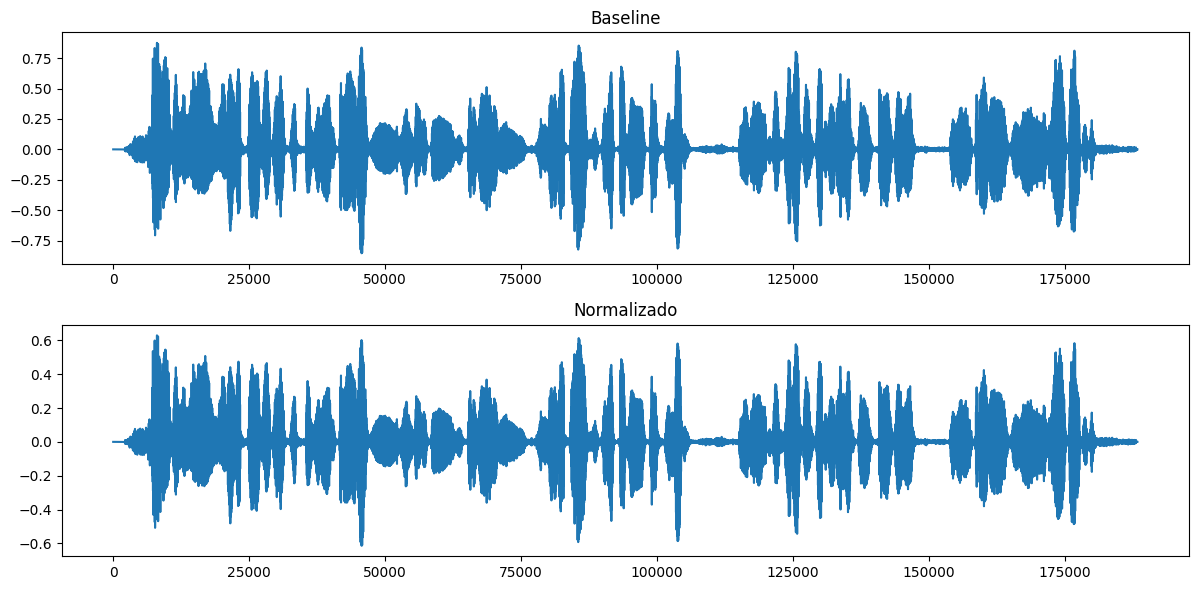

In [56]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(base)
plt.title("Baseline")

plt.subplot(2, 1, 2)
plt.plot(norm)
plt.title("Normalizado")

plt.tight_layout()
plt.show()

# INSERTAR COMENTARIOS

#### 5.5.3 Evaluación cualitativa mediante escucha (*listening test*)

In [57]:
print("Baseline")
display(Audio(base, rate=16000))

print("Normalizado")
display(Audio(norm, rate=16000))

print("Denoised")
display(Audio(denoise, rate=16000))

print("VAD")
display(Audio(vad, rate=16000))

Baseline


Normalizado


Denoised


VAD


# INSERTAR COMENTARIOS

#### 5.5.4 Conclusiones

# INSERTAR COMENTARIOS

## 6. Generación de audios procesados

### 6.2 Trazabilidad:

- nombre archivo
- timestamp
- versión de procesamiento aplicada

### 6.1 Exportación de audios limpios

## 7. Evaluación del procesamiento (esto te falta)

### 7.1 Métricas objetivas (aproximadas):

- SNR (Signal-to-Noise Ratio)
- energía media
- reducción de silencio (%)

### 7.2 Evaluación cualitativa:

- comparación visual (waveform / espectrograma)
- inspección auditiva controlada

### 7.3 Comparativa entre configuraciones:

- sin procesado vs procesado
- método A vs método B

👉 Esto es lo que luego te permite decir:
“este preprocesamiento mejora el ASR”

## 8. Selección del pipeline final
- Justificación de decisiones:
- método de reducción de ruido elegido
- normalización
- uso o no de VAD

## 9. Output del notebook
- Audios listos para ASR
- Estructura de carpetas clara
- Relación input → output

## 10. Conclusiones
- Resumen del proceso aplicado
- Resultados principales
- Relevancia para el pipeline de Speech-to-Text

🎯 **Resumen breve (para tus notas)**

| Parte      | Dependencias clave                         |
| ---------- | ------------------------------------------ |
| **Audio**  | librosa, pydub, soundfile, numpy           |
| **STT**    | faster-whisper                             |
| **NLP**    | spacy, transformers, sentence-transformers |
| **Extras** | pandas, scikit-learn, matplotlib           |